In [8]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


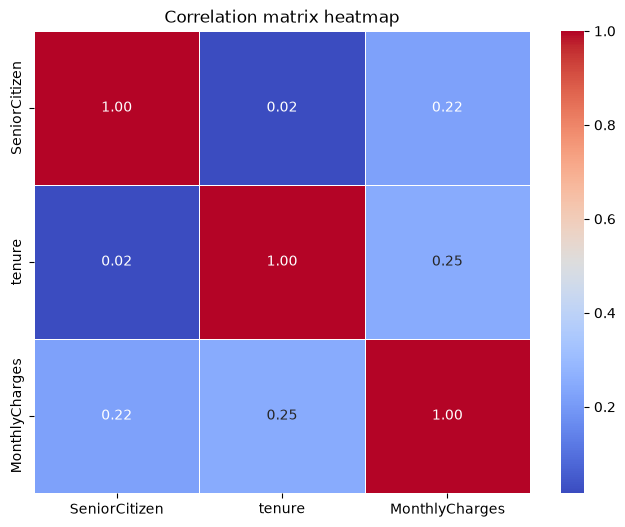

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f",
    linewidths = 0.5
)
plt.title("Correlation matrix heatmap")
plt.show()

In [10]:
df.to_csv("Preprocessed_Data.csv",index=False)
print("Saved")

Saved


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("Preprocessed_Data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
x = df.drop("tenure",axis=1)
y = df["tenure"]
x = pd.get_dummies(x,drop_first=True)
x_train , x_test , y_train , y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Features: ",x_train.shape)
print("Testing Features: ",x_test.shape)

print("Training Target: ",y_train.shape)
print("Training Target: ",y_test.shape)
print("Training data")
print(x_train.head())

print("\nTesting data")
print(x_test.head())

Training Features:  (5634, 13601)
Testing Features:  (1409, 13601)
Training Target:  (5634,)
Training Target:  (1409,)
Training data
      SeniorCitizen  MonthlyCharges  customerID_0003-MKNFE  \
2142              0           64.85                  False   
1623              0           97.20                  False   
6074              0           23.45                  False   
1362              0           70.20                  False   
6754              0           61.90                  False   

      customerID_0004-TLHLJ  customerID_0011-IGKFF  customerID_0013-EXCHZ  \
2142                  False                  False                  False   
1623                  False                  False                  False   
6074                  False                  False                  False   
1362                  False                  False                  False   
6754                  False                  False                  False   

      customerID_0013-MHZWF  cu

In [13]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [23]:
df['tenure']

0        1
1       34
2        2
3       45
4        2
        ..
7038    24
7039    72
7040    11
7041     4
7042    66
Name: tenure, Length: 7032, dtype: int64

In [25]:
import numpy as np
X = df['tenure']
Y = df['TotalCharges']
m = ((X - X.mean())*(Y - Y.mean()))/((X - X.mean())**2).sum()
c=Y.mean() - m*X.mean()
Y_pred = m*X+c
print(Y_pred)
Y_pred = np.round(Y_pred).astype(int)
print(Y_pred.head())
print("Slope: ",m)
print("Intercept: ",c)



0       2282.775201
1       2283.300209
2       2282.825208
3       2283.283912
4       2282.834712
           ...     
7038    2283.295538
7039    2285.178847
7040    2283.090617
7041    2282.923484
7042    2284.514506
Length: 7032, dtype: float64
0    2283
1    2283
2    2283
3    2283
4    2283
dtype: int64
Slope:  0       0.016716
1      -0.000147
2       0.015621
3      -0.001314
4       0.015309
          ...   
7038    0.000582
7039    0.047461
7040    0.009795
7041    0.013263
7042    0.036156
Length: 7032, dtype: float64
Intercept:  0       2282.758486
1       2283.305198
2       2282.793965
3       2283.343046
4       2282.804094
           ...     
7038    2283.281567
7039    2281.761683
7040    2282.982873
7041    2282.870433
7042    2282.128188
Length: 7032, dtype: float64


In [22]:
plt.figure(figsize=(8,5))
plt.scatter(X,Y)
plt.plot(X,Y_pred,color="red")
plt.title("simple linear chart")
plt.xlabel("tenure")
plt.ylabel("TotalCharges")
plt.show()

NameError: name 'Y' is not defined

<Figure size 800x500 with 0 Axes>